# Net2Brain 3D NN

## extracting Data, RDM, and RSA

In [ ]:
# CONFIGURATION
import os

from pathlib import Path

bonner_path = Path("../bonner_pnas2017")  #PATH_TO_BONNER_DATASET

stimuli_path = os.path.join(bonner_path, "stimuli_data")

etc_path = os.path.join(bonner_path, "etc")

print(stimuli_path)
print(os.path.exists(stimuli_path))

..\bonner_pnas2017\stimuli_data
True


In [2]:
# Path for RSA

bonner_path = Path("../bonner_pnas2017")  #PATH_TO_BONNER_DATASET

# All visual cortex ROIs
visual_roi_path = bonner_path / "brain_data"

# PPA
ppa_roi_path = bonner_path / "brain_data_live_study"

# Clean PPA folder used for RSA
ppa_rsa_path = Path(
    "../PPA_RSA_clean"
)
print("Visual ROI path:", visual_roi_path)
print("PPA ROI path:", ppa_roi_path)

print("\nVisual ROI files:")
for f in sorted(visual_roi_path.glob("*.npz")):
    print(f.name)

print("\nPPA files:")
for f in sorted(ppa_roi_path.glob("*.npz")):
    print(f.name)

print("\nPPA RSA files:")
for f in ppa_rsa_path.iterdir():
    print(f.name)

Visual ROI path: ..\bonner_pnas2017\brain_data
PPA ROI path: ..\bonner_pnas2017\brain_data_live_study

Visual ROI files:
fmri_hV4.npz
fmri_LO1.npz
fmri_LO2.npz
fmri_PHC1.npz
fmri_PHC2.npz
fmri_V1d.npz
fmri_V1v.npz
fmri_V2d.npz
fmri_V2v.npz
fmri_V3a.npz
fmri_V3b.npz
fmri_V3d.npz
fmri_V3v.npz
fmri_VO1.npz
fmri_VO2.npz

PPA files:
fmri_ppa.npz
fmri_ppa_vpa_vectorized.npz

PPA RSA files:
fmri_ppa.npz
noise_ceiling_log.json


### depth

In [3]:
from net2brain.feature_extraction import FeatureExtractor

fx_3d = FeatureExtractor(model='depth', 
                            netset='Taskonomy', 
                            device='cuda')



In [4]:
# Create features for the 3D model
fx_3d.extract(data_path=stimuli_path, 
                 save_path='Depth_feats_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:02<00:00, 24.01it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 142.62it/s]


#### RDM

In [5]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs 
creator_3d = RDMCreator(verbose=True, device='cuda')
creator_3d.create_rdms(feature_path="Depth_feats_last2", save_path="Depth_RDMs_last2", save_format='npz') 



c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Depth_RDMs_last2')

Found: 2 RDM files
Depth_RDMs_last2\RDM_layer3.npz
Depth_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

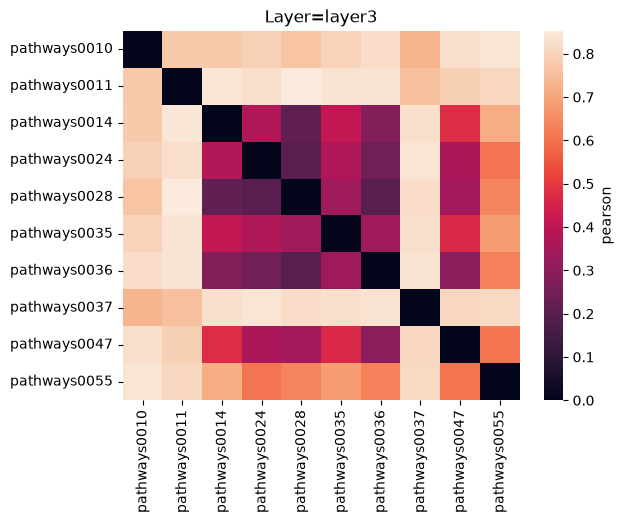

In [6]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Depth_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files:
    print(f)


from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Depth_RDMs_last2/RDM_layer3.npz")         # Change the layer name to visualize different layers
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [7]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Depth_RDMs_last2"

# Start RSA
depth_visual_evaluation = RSA(
    model_rdms,
    str(visual_roi_path),
    model_name="Taskonomy Depth"
)

df_depth_visual = depth_visual_evaluation.evaluate()

display(df_depth_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy Depth,0.005460,5.662509,"[0.0026262210229590307, 0.001617790179116667, ...",2.599621e-03,0.001515,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy Depth,0.002440,2.530939,"[0.0021044631511767534, 0.0013775878665894365,...",2.500651e-03,0.000673,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy Depth,0.000610,1.800405,"[0.0010268883493483314, 0.0011777184937752688,...",3.090409e-02,0.000256,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy Depth,0.000295,0.870041,"[9.207071750144476e-05, 0.0014104502836923196,...",2.038337e-02,0.000114,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy Depth,0.000784,4.978014,"[0.0054940304305384265, 0.0010352621664358331,...",5.022498e-02,0.000368,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy Depth,0.000504,3.199476,"[0.0012368919006359835, 0.002140251984844312, ...",1.710199e-02,0.000188,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy Depth,0.000909,2.383597,"[0.003032019248540517, 8.091092289522228e-07, ...",7.930111e-03,0.000297,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy Depth,0.000503,1.317681,"[0.000783397449955855, 6.031953725560663e-06, ...",6.728205e-03,0.000160,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy Depth,0.000302,1.127362,"[0.0003462097271019184, 3.3901007578399916e-06...",4.226679e-02,0.000136,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy Depth,0.000227,0.847695,"[0.0003549443435805012, 0.00023973973519962342...",3.922614e-04,0.000050,0.026776,0.103791


In [8]:
# against PPa

depth_ppa_evaluation = RSA(
    "./Depth_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy Depth"
)

df_depth_ppa = depth_ppa_evaluation.evaluate()

display(df_depth_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy Depth,0.000639,5.770924,"[0.0024875707132252915, 0.0027762205602591783,...",0.008266,0.000210,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy Depth,0.000512,4.624647,"[0.0008599825681064629, 0.0016030199230529537,...",0.014724,0.000186,0.011077,0.084378


### Depth euclidean


In [9]:
from net2brain.feature_extraction import FeatureExtractor

fx_euc = FeatureExtractor(model='euclidean', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_euc.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [10]:
# Create features for the 3D model
fx_euc.extract(data_path=stimuli_path, 
                 save_path='Euclidean_feats_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:01<00:00, 33.69it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 144.06it/s]


#### RDM

In [11]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs 
creator_euclidean = RDMCreator(verbose=True, device='cuda')
creator_euclidean.create_rdms(feature_path="Euclidean_feats_last2", save_path="Euclidean_RDMs_last2", save_format='npz', dim_reduction='scp') #

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Euclidean_RDMs_last2')

Found: 2 RDM files
Euclidean_RDMs_last2\RDM_layer3.npz
Euclidean_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

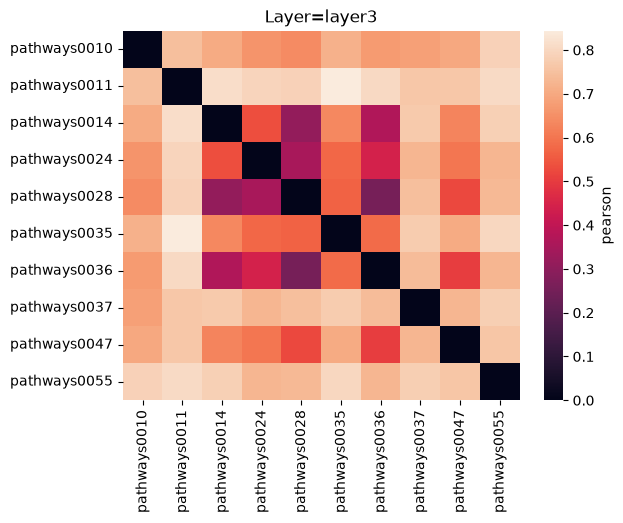

In [12]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Euclidean_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)


from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Euclidean_RDMs_last2/RDM_layer3.npz")     # Change the layer name to visualize different layers
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [13]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Euclidean_RDMs_last2"

# Start RSA
euclidean_visual_evaluation = RSA(model_rdms, 
                 str(visual_roi_path), 
                 model_name="Taskonomy Euclidean")

df_euc_visual = euclidean_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_euc_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy Euclidean,0.004176,4.330537,"[0.0016044906838271788, 0.002676605196627416, ...",2.165232e-03,0.001130,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy Euclidean,0.003605,3.739037,"[0.0037840134024493947, 0.0024084796350063776,...",7.438509e-04,0.000855,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001085,3.202924,"[0.0017668841477632119, 0.002676536976263798, ...",2.630916e-02,0.000440,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001114,3.288827,"[0.0019388757543585308, 0.005918169969461816, ...",1.733724e-02,0.000417,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001156,7.339430,"[0.005161217075769102, 0.001642685127392468, 5...",2.348902e-02,0.000459,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001281,8.131839,"[0.005429934884359487, 0.004478472669936031, 4...",1.826110e-02,0.000484,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001381,3.621139,"[0.0034455936749912203, 1.4339213056073314e-05...",8.195832e-03,0.000454,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001258,3.299686,"[0.0038656328733824834, 4.208319344794666e-05,...",8.719656e-03,0.000418,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy Euclidean,0.000621,2.318594,"[0.0006803781036294163, 3.7963423571005185e-06...",5.104673e-02,0.000293,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy Euclidean,0.000516,1.926189,"[0.0008853037869313702, 3.876585225394219e-05,...",5.923845e-02,0.000253,0.026776,0.103791


In [14]:
# against PPa

euc_ppa_evaluation = RSA(
    "./Euclidean_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy Euclidean"
)

df_euc_ppa = euc_ppa_evaluation.evaluate()

display(df_euc_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy Euclidean,0.000893,8.059042,"[0.0021797479942371437, 0.004371562761351227, ...",0.008467,0.000295,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy Euclidean,0.000921,8.318773,"[0.0012774352605529216, 0.005649750105246847, ...",0.022048,0.000361,0.011077,0.084378


### keypoints3d

In [15]:
from net2brain.feature_extraction import FeatureExtractor

fx_kp3d = FeatureExtractor(model='keypoints3d', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_kp3d.layers_to_extract)



['layer1', 'layer2', 'layer3', 'layer4']


In [16]:
# Create features for the 3D model
fx_kp3d.extract(data_path=stimuli_path, 
                 save_path='KeyPoints3D_feats_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:01<00:00, 32.53it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 151.38it/s]


#### RDM

In [17]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs
creator_keypoints3d = RDMCreator(verbose=True, device='cuda')
creator_keypoints3d.create_rdms(feature_path="KeyPoints3D_feats_last2", save_path="KeyPoints3D_RDMs_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('KeyPoints3D_RDMs_last2')

Found: 2 RDM files
Keypoints3D_RDMs_last2\RDM_layer3.npz
Keypoints3D_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

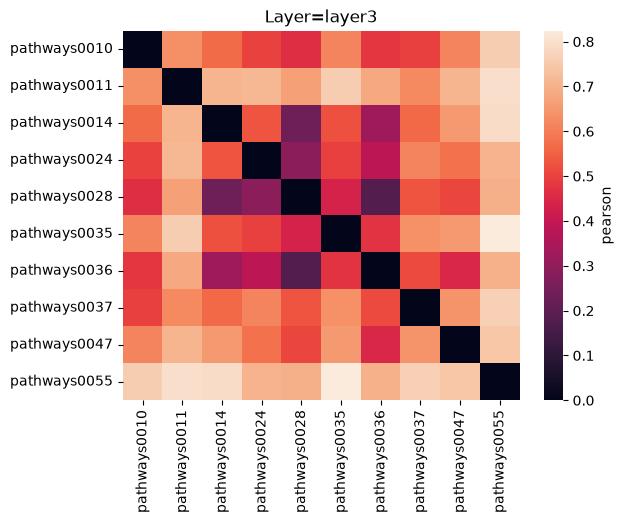

In [18]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Keypoints3D_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Keypoints3D_RDMs_last2/RDM_layer3.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [19]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./KeyPoints3D_RDMs_last2"

# Start RSA
keypoints3d_visual_evaluation = RSA(model_rdms, 
                 str(visual_roi_path), 
                 model_name="Taskonomy KeyPoints3D")

df_kp3d_visual = keypoints3d_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_kp3d_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.001662,1.723358,"[0.0007944249479253121, 0.0027239458336754197,...",1.257561e-03,0.000420,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.003429,3.556583,"[0.0010863488832517083, 0.008517875318312617, ...",1.557213e-03,0.000890,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000359,1.059377,"[0.000433907224058995, 0.0021539338065580203, ...",3.406296e-02,0.000154,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.001296,3.827610,"[0.0018194618344397214, 0.0068587900308266815,...",1.850786e-02,0.000491,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000527,3.345686,"[0.002389761989390112, 0.002326450269373352, 0...",1.886578e-02,0.000200,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.001456,9.244954,"[0.004338290472959586, 0.007598661275370805, 2...",1.973054e-02,0.000558,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000687,1.801079,"[0.0018351923825526816, 8.27900213110785e-05, ...",8.491329e-03,0.000227,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.001322,3.466535,"[0.002269891380523215, 0.0003496534551391271, ...",6.122257e-03,0.000415,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000426,1.590595,"[0.0011309747130116776, 0.0005385211711807647,...",4.475100e-02,0.000194,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000585,2.185755,"[0.0005579493950839032, 0.0005985929070806568,...",3.140214e-02,0.000247,0.026776,0.103791


In [20]:
# against PPa

keypoints3d_ppa_evaluation = RSA(
    "./KeyPoints3D_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy KeyPoints3D"
)

df_kp3d_ppa = keypoints3d_ppa_evaluation.evaluate()

display(df_kp3d_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000625,5.645417,"[0.00282129975489661, 0.0025653625523808106, 2...",0.013743,0.000224,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000899,8.115005,"[0.00305439880192468, 0.005459467735955537, 0....",0.025598,0.000363,0.011077,0.084378


### normal

In [21]:
from net2brain.feature_extraction import FeatureExtractor

fx_normal = FeatureExtractor(model='normal', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_normal.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [22]:
# Create features for the 3D model
fx_normal.extract(data_path=stimuli_path, 
                  save_path='Normal_feats_last2',
                  layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:01<00:00, 28.52it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 95.32it/s] 


#### RDM

In [23]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_normal = RDMCreator(verbose=True, device='cuda')
creator_normal.create_rdms(feature_path="Normal_feats_last2", save_path="Normal_RDMs_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Normal_RDMs_last2')

Found: 2 RDM files
Normal_RDMs_last2\RDM_layer3.npz
Normal_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer4 with 6 stimuli


<Axes: title={'center': 'Layer=layer4'}>

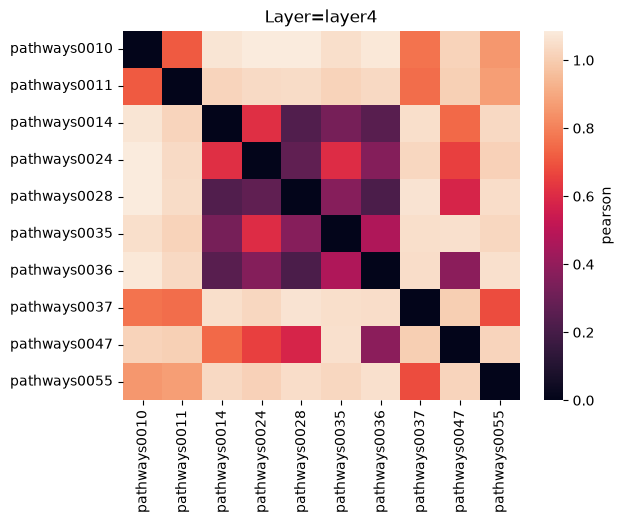

In [24]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Normal_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Normal_RDMs_last2/RDM_layer4.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [25]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Normal_RDMs_last2"

# Start RSA
normal_visual_evaluation = RSA(model_rdms, 
                 str(visual_roi_path), 
                 model_name="Taskonomy Normal")

df_normal_visual = normal_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_normal_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy Normal,0.021954,22.768308,"[0.009697798458126999, 0.006065910632209469, 0...",3.427210e-03,0.006326,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy Normal,0.023424,24.293087,"[0.011984142557481491, 0.009525176251629755, 0...",2.687334e-03,0.006527,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy Normal,0.001983,5.854471,"[0.0020146299401033016, 0.0008086287897610998,...",1.214234e-01,0.001208,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy Normal,0.001891,5.584809,"[0.0020874020971872785, 0.0016565027050998659,...",9.283264e-02,0.001054,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy Normal,0.001716,10.890229,"[0.008894826392827682, 0.0007162067441000088, ...",7.003646e-02,0.000880,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy Normal,0.001463,9.284889,"[0.0064364712078932495, 0.0017420306948501797,...",4.301969e-02,0.000662,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy Normal,0.002638,6.917459,"[0.008261644833109934, 2.0667016362257907e-05,...",2.265334e-03,0.000718,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy Normal,0.002791,7.318306,"[0.01072335704423133, 0.000899572734607914, 0....",5.186278e-03,0.000854,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy Normal,0.001032,3.854494,"[0.0006896581380754169, 3.4555398216548885e-05...",2.030229e-02,0.000398,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy Normal,0.001170,4.368425,"[0.0014070979791713629, 0.00042075697641831246...",1.705330e-02,0.000436,0.026776,0.103791


In [26]:
# against PPa

normal_ppa_evaluation = RSA(
    "./Normal_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy Normal"
)

df_normal_ppa = normal_ppa_evaluation.evaluate()

display(df_normal_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy Normal,0.001586,14.315182,"[0.0026032645670065915, 0.0075771134201942265,...",0.004220,0.000471,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy Normal,0.001823,16.456271,"[0.0025517763176976446, 0.009793826127317124, ...",0.007272,0.000587,0.011077,0.084378


### Curvature

In [27]:
from net2brain.feature_extraction import FeatureExtractor

fx_curvature = FeatureExtractor(model='curvature', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_curvature.layers_to_extract)

['layer1', 'layer2', 'layer3', 'layer4']


In [28]:
# Create features for the 3D model
fx_curvature.extract(data_path=stimuli_path, 
                  save_path='Curvature_feats_last2',
                  layers_to_extract=[ 'layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:01<00:00, 30.64it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 147.25it/s]


#### RDM

In [29]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_curvature = RDMCreator(verbose=True, device='cuda')
creator_curvature.create_rdms(feature_path="Curvature_feats_last2", save_path="Curvature_RDMs_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Curvature_RDMs_last2')

Found: 2 RDM files
Curvature_RDMs_last2\RDM_layer3.npz
Curvature_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer4 with 6 stimuli


<Axes: title={'center': 'Layer=layer4'}>

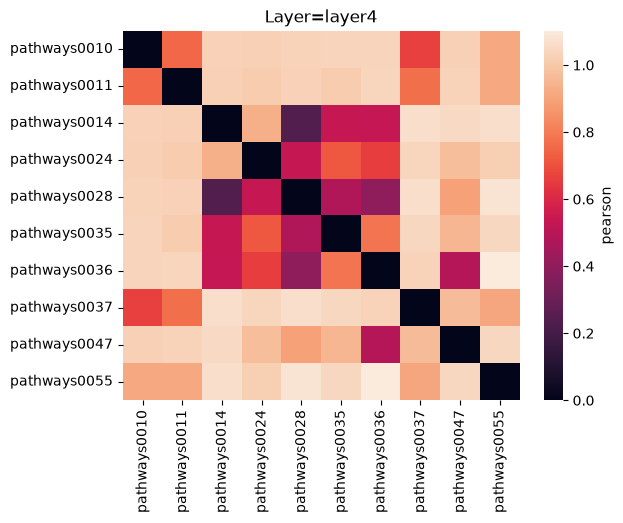

In [30]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Curvature_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Curvature_RDMs_last2/RDM_layer4.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [31]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Curvature_RDMs_last2"

# Start RSA
curvature_visual_evaluation = RSA(model_rdms, 
                 str(visual_roi_path), 
                 model_name="Taskonomy Curvature")

df_curvature_visual = curvature_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_curvature_visual)



,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy Curvature,0.006497,6.737765,"[0.00444842648254451, 0.002006553533440522, 6....",0.005809,0.002022,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy Curvature,0.007788,8.077329,"[0.006628923063401042, 0.006525143490132064, 5...",0.004439,0.002329,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy Curvature,0.000355,1.048781,"[2.5912121752042827e-05, 0.0003432248044696020...",0.004916,0.000108,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy Curvature,0.000629,1.858140,"[0.00015594338023014798, 0.0029301464189441535...",0.032112,0.000266,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy Curvature,0.000789,5.009143,"[0.0033128939106816706, 0.0006152677187047636,...",0.003168,0.000225,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy Curvature,0.000937,5.949924,"[0.002856435658896596, 0.00240832394024185, 0....",0.001891,0.000249,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy Curvature,0.000978,2.564977,"[0.004038431679914763, 9.171115448030286e-05, ...",0.019043,0.000372,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy Curvature,0.001300,3.408967,"[0.004546466814968421, 5.848020431890259e-07, ...",0.020540,0.000502,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy Curvature,0.000649,2.422358,"[0.0002235100995579038, 3.0028963664754915e-05...",0.112292,0.000384,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy Curvature,0.000928,3.466154,"[2.02358191713217e-06, 8.590697199870257e-05, ...",0.130836,0.000581,0.026776,0.103791


In [32]:
# against PPa

curvature_ppa_evaluation = RSA(
    "./Curvature_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy Curvature"
)

df_curvature_ppa = curvature_ppa_evaluation.evaluate()

display(df_curvature_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy Curvature,0.001063,9.598039,"[0.004568203170361741, 0.003116636760663283, 0...",0.005159,0.000325,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy Curvature,0.001226,11.064375,"[0.007981433279077953, 0.0016515895608343923, ...",0.024597,0.000491,0.011077,0.084378


### Room_layout

In [33]:
from net2brain.feature_extraction import FeatureExtractor

fx_roomLayout = FeatureExtractor(model='room_layout', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_roomLayout.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [34]:
# Create features for the 3D model
fx_roomLayout.extract(data_path=stimuli_path, 
                  save_path='RoomLayout_feats_last2',
                  layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 50/50 [00:01<00:00, 35.29it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 149.21it/s]


#### RDM

In [35]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_roomLayout = RDMCreator(verbose=True, device='cuda')
creator_roomLayout.create_rdms(feature_path="RoomLayout_feats_last2", save_path="RoomLayout_RDMs_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('RoomLayout_RDMs_last2')

Found: 2 RDM files
RoomLayout_RDMs_last2\RDM_layer3.npz
RoomLayout_RDMs_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

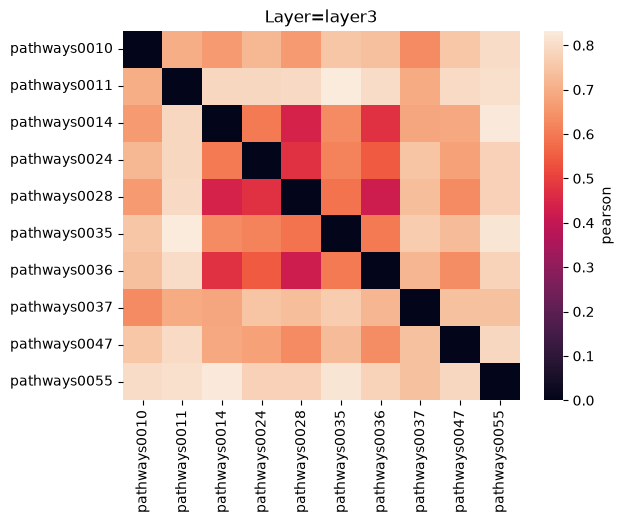

In [36]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("RoomLayout_RDMs_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("RoomLayout_RDMs_last2/RDM_layer3.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [37]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./RoomLayout_RDMs_last2"

# Start RSA
roomLayout_visual_evaluation = RSA(model_rdms, 
                 str(visual_roi_path), 
                 model_name="Taskonomy Room Layout")

df_roomLayout_visual = roomLayout_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_roomLayout_visual)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_hV4,(0) RDM_layer3.npz,Taskonomy Room Layout,0.009763,10.125581,"[0.0017560490088152187, 0.008337434800884724, ...",2.003065e-03,0.002616,0.096422,0.178729
1,(0) fmri_hV4,(1) RDM_layer4.npz,Taskonomy Room Layout,0.018028,18.697466,"[0.004320575139883745, 0.011388563373411363, 0...",1.560273e-03,0.004678,0.096422,0.178729
2,(1) fmri_LO1,(0) RDM_layer3.npz,Taskonomy Room Layout,0.002095,6.185126,"[0.0035414163743097064, 0.0038370382443182354,...",2.225344e-02,0.000822,0.033866,0.116975
3,(1) fmri_LO1,(1) RDM_layer4.npz,Taskonomy Room Layout,0.003267,9.646227,"[0.005549665302885004, 0.004834380675917917, 0...",3.943322e-03,0.000960,0.033866,0.116975
4,(2) fmri_LO2,(0) RDM_layer3.npz,Taskonomy Room Layout,0.002060,13.078699,"[0.009747478392184625, 0.0025737595834837102, ...",3.230907e-02,0.000873,0.015754,0.091751
5,(2) fmri_LO2,(1) RDM_layer4.npz,Taskonomy Room Layout,0.003088,19.601745,"[0.013646682199789095, 0.0024407542260411904, ...",1.783055e-02,0.001161,0.015754,0.091751
6,(3) fmri_PHC1,(0) RDM_layer3.npz,Taskonomy Room Layout,0.002263,5.933894,"[0.005594022691206927, 0.00019741529747313138,...",8.849690e-03,0.000753,0.038140,0.119031
7,(3) fmri_PHC1,(1) RDM_layer4.npz,Taskonomy Room Layout,0.003455,9.058409,"[0.008172460398390221, 0.0003789103562677949, ...",5.336646e-03,0.001062,0.038140,0.119031
8,(4) fmri_PHC2,(0) RDM_layer3.npz,Taskonomy Room Layout,0.001100,4.108284,"[0.0008463840946408632, 0.0009798999287778045,...",3.939856e-02,0.000488,0.026776,0.103791
9,(4) fmri_PHC2,(1) RDM_layer4.npz,Taskonomy Room Layout,0.001705,6.368529,"[0.0005718261419536966, 0.0005372984589853733,...",4.135767e-02,0.000764,0.026776,0.103791


In [38]:
# against PPa

roomLayout_ppa_evaluation = RSA(
    "./RoomLayout_RDMs_last2",
    str(ppa_rsa_path),
    model_name="Taskonomy Room Layout"
)

df_roomLayout_ppa = roomLayout_ppa_evaluation.evaluate()

display(df_roomLayout_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_ppa,(0) RDM_layer3.npz,Taskonomy Room Layout,0.001033,9.330165,"[0.0032459563463060363, 0.005322064744870482, ...",0.008897,0.000344,0.011077,0.084378
1,(0) fmri_ppa,(1) RDM_layer4.npz,Taskonomy Room Layout,0.001902,17.172234,"[0.006780232984519928, 0.008710399497872305, 0...",0.007619,0.000618,0.011077,0.084378


## verify Features

In [39]:
## verify all feature exists
import os

feature_folders = [
    "Depth_feats_last2",
    "Euclidean_feats_last2",
    "Keypoints3D_feats_last2",
    "Normal_feats_last2",
    "Curvature_feats_last2",
    "RoomLayout_feats_last2"
]

for folder in feature_folders:
    exists = os.path.exists(folder)
    
    if exists:
        files = os.listdir(folder)
        print(f"✓ {folder}")
        print(f"  Number of items: {len(files)}")
    else:
        print(f"✗ {folder} NOT FOUND")



✓ Depth_feats_last2
  Number of items: 2
✓ Euclidean_feats_last2
  Number of items: 2
✓ Keypoints3D_feats_last2
  Number of items: 2
✓ Normal_feats_last2
  Number of items: 2
✓ Curvature_feats_last2
  Number of items: 2
✓ RoomLayout_feats_last2
  Number of items: 2


## Evaluation

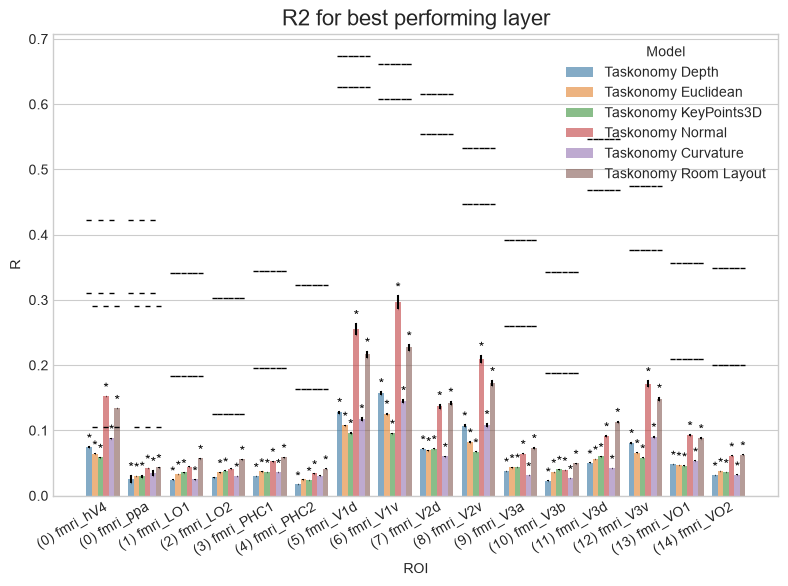

In [40]:
from net2brain.evaluations.plotting import Plotting

# Plotting with significance
plotter = Plotting([df_depth_visual, df_depth_ppa, df_euc_visual, df_euc_ppa, df_kp3d_visual, df_kp3d_ppa, df_normal_visual, df_normal_ppa, df_curvature_visual, df_curvature_ppa, df_roomLayout_visual, df_roomLayout_ppa])
results_dataframe = plotter.plot(metric = "R")

In [41]:
#dataframe containing all layers

import pandas as pd
import re

all_layers_data = []

ppa_results = {
    "Depth": df_depth_ppa,
    "Euclidean": df_euc_ppa,
    "Keypoints3D": df_kp3d_ppa,
    "Normal": df_normal_ppa,
    "Curvature": df_curvature_ppa,
    "Room Layout": df_roomLayout_ppa
}

visual_results = {
    "Depth": df_depth_visual,
    "Euclidean": df_euc_visual,
    "Keypoints3D": df_kp3d_visual,
    "Normal": df_normal_visual,
    "Curvature": df_curvature_visual,
    "Room Layout": df_roomLayout_visual  # no R data for Room Layout 
}

all_results = ppa_results.copy()  # visual_results.copy()

for model_name, df in all_results.items():
    for _, row in df.iterrows():
        layer_match = re.search(r'layer(\d+)', row["Layer"])
        
        if layer_match:
            layer_number = int(layer_match.group(1))
        else:
            layer_number = None
        
        all_layers_data.append({
            "Model": model_name,
            "Layer_Number": layer_number,
            "R": row.get("R", None),
            "R2": row["R2"],
            "SEM": row["SEM"],
            "Significance": row["Significance"],
            "ROI": row["ROI"]
        })


df_all_layers = pd.DataFrame(all_layers_data)

df_all_layers = df_all_layers.sort_values(
    ["Layer_Number", "Model"]
).reset_index(drop=True)

display(df_all_layers)

,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,Curvature,3,0.032606,0.001063,0.000325,0.005159,(0) fmri_ppa
1,Depth,3,0.025283,0.000639,0.000210,0.008266,(0) fmri_ppa
2,Euclidean,3,0.029877,0.000893,0.000295,0.008467,(0) fmri_ppa
3,Keypoints3D,3,0.025006,0.000625,0.000224,0.013743,(0) fmri_ppa
4,Normal,3,0.039820,0.001586,0.000471,0.004220,(0) fmri_ppa
5,Room Layout,3,0.032147,0.001033,0.000344,0.008897,(0) fmri_ppa
6,Curvature,4,0.035008,0.001226,0.000491,0.024597,(0) fmri_ppa
7,Depth,4,0.022633,0.000512,0.000186,0.014724,(0) fmri_ppa
8,Euclidean,4,0.030355,0.000921,0.000361,0.022048,(0) fmri_ppa
9,Keypoints3D,4,0.029981,0.000899,0.000363,0.025598,(0) fmri_ppa


In [42]:
# FUNCTION: convert RSA result dataframes into one dataframe

def prepare_layer_dataframe(results_dict, dataset_name):
    layers_data = []
    for model_name, df in results_dict.items():

        missing = [
            col for col in
            ["R", "R2", "SEM", "Significance", "ROI", "Layer"]
            if col not in df.columns
        ]
        if missing:
            print(f"{model_name} missing: {missing}")


        for _, row in df.iterrows():
            # Extract numerical layer number
            layer_match = re.search(
                r'layer(\d+)',
                str(row["Layer"]),
                re.IGNORECASE
            )

            if layer_match:
                layer_number = int(layer_match.group(1))
            else:
                layer_number = None

            layers_data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Layer_Number": layer_number,
                "R": row.get("R"),
                "R2": row["R2"],
                "SEM": row["SEM"],
                "Significance": row["Significance"],
                "ROI": row["ROI"]
            })

    return pd.DataFrame(layers_data)

df_visual_layers = prepare_layer_dataframe(
    visual_results,
    "Visual"
)


df_ppa_layers = prepare_layer_dataframe(
    ppa_results,
    "PPA"
)

print("VISUAL:")
print(df_visual_layers.shape)
display(df_visual_layers.head())


print("\nPPA:")
print(df_ppa_layers.shape)
display(df_ppa_layers.head())

VISUAL:
(180, 8)


,Dataset,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,Visual,Depth,3,0.073891,0.005460,0.001515,0.002600,(0) fmri_hV4
1,Visual,Depth,4,0.049400,0.002440,0.000673,0.002501,(0) fmri_hV4
2,Visual,Depth,3,0.024693,0.000610,0.000256,0.030904,(1) fmri_LO1
3,Visual,Depth,4,0.017165,0.000295,0.000114,0.020383,(1) fmri_LO1
4,Visual,Depth,3,0.028004,0.000784,0.000368,0.050225,(2) fmri_LO2



PPA:
(12, 8)


,Dataset,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,PPA,Depth,3,0.025283,0.000639,0.000210,0.008266,(0) fmri_ppa
1,PPA,Depth,4,0.022633,0.000512,0.000186,0.014724,(0) fmri_ppa
2,PPA,Euclidean,3,0.029877,0.000893,0.000295,0.008467,(0) fmri_ppa
3,PPA,Euclidean,4,0.030355,0.000921,0.000361,0.022048,(0) fmri_ppa
4,PPA,Keypoints3D,3,0.025006,0.000625,0.000224,0.013743,(0) fmri_ppa


In [43]:
# combine visual and PPA dataframes into one dataframe

df_roi_layers = pd.concat(
    [
        df_visual_layers,
        df_ppa_layers
    ],
    ignore_index=True
)

df_roi_layers = df_roi_layers.sort_values(
    [
        "Dataset",
        "ROI",
        "Model",
        "Layer_Number"
    ]
).reset_index(drop=True)

In [44]:
def assign_roi_group(roi):
    roi = str(roi).lower()

    if "v1d" in roi or "v1v" in roi:
        return "V1"

    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    elif "hv4" in roi:
        return "V4"

    elif "ppa" in roi:
        return "PPA"

    else:
        return None


df_roi_layers["ROI_Group"] = (
    df_roi_layers["ROI"]
    .apply(assign_roi_group)
)

df_v1_v2_v4_ppa = df_roi_layers[
    df_roi_layers["ROI_Group"].isin(
        ["V1", "V2", "V4", "PPA"]
    )
].copy()

print(
    df_v1_v2_v4_ppa[
        ["ROI", "ROI_Group"]
    ]
    .drop_duplicates()
    .sort_values("ROI_Group")
)


              ROI ROI_Group
0    (0) fmri_ppa       PPA
132  (5) fmri_V1d        V1
144  (6) fmri_V1v        V1
156  (7) fmri_V2d        V2
168  (8) fmri_V2v        V2
12   (0) fmri_hV4        V4


In [45]:
def assign_roi_group(roi):
    roi = str(roi).lower()

    # V1
    if "v1d" in roi or "v1v" in roi:
        return "V1"

    # V2
    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    # V4
    elif "hv4" in roi:
        return "V4"

    # PPA
    elif "ppa" in roi:
        return "PPA"

    else:
        return None

df_roi_layers["ROI_Group"] = (
    df_roi_layers["ROI"]
    .apply(assign_roi_group)
)

df_plot = df_roi_layers[
    df_roi_layers["ROI_Group"].isin(
        ["V1", "V2", "V4", "PPA"]
    )
].copy()

print(
    df_v1_v2_v4_ppa[
        ["ROI", "ROI_Group"]
    ]
    .drop_duplicates()
    .sort_values("ROI_Group")
)


              ROI ROI_Group
0    (0) fmri_ppa       PPA
132  (5) fmri_V1d        V1
144  (6) fmri_V1v        V1
156  (7) fmri_V2d        V2
168  (8) fmri_V2v        V2
12   (0) fmri_hV4        V4


In [46]:
df_plot_summary = (
    df_plot
    .groupby(
        [
            "Model",
            "ROI_Group",
            "Layer_Number"
        ]
    )["R"]
    .mean()
    .reset_index()
)

display(df_plot_summary)

,Model,ROI_Group,Layer_Number,R
0,Curvature,PPA,3,0.032606
1,Curvature,PPA,4,0.035008
2,Curvature,V1,3,0.130661
3,Curvature,V1,4,0.130107
4,Curvature,V2,3,0.078820
5,Curvature,V2,4,0.084503
6,Curvature,V4,3,0.080602
7,Curvature,V4,4,0.088251
8,Depth,PPA,3,0.025283
9,Depth,PPA,4,0.022633


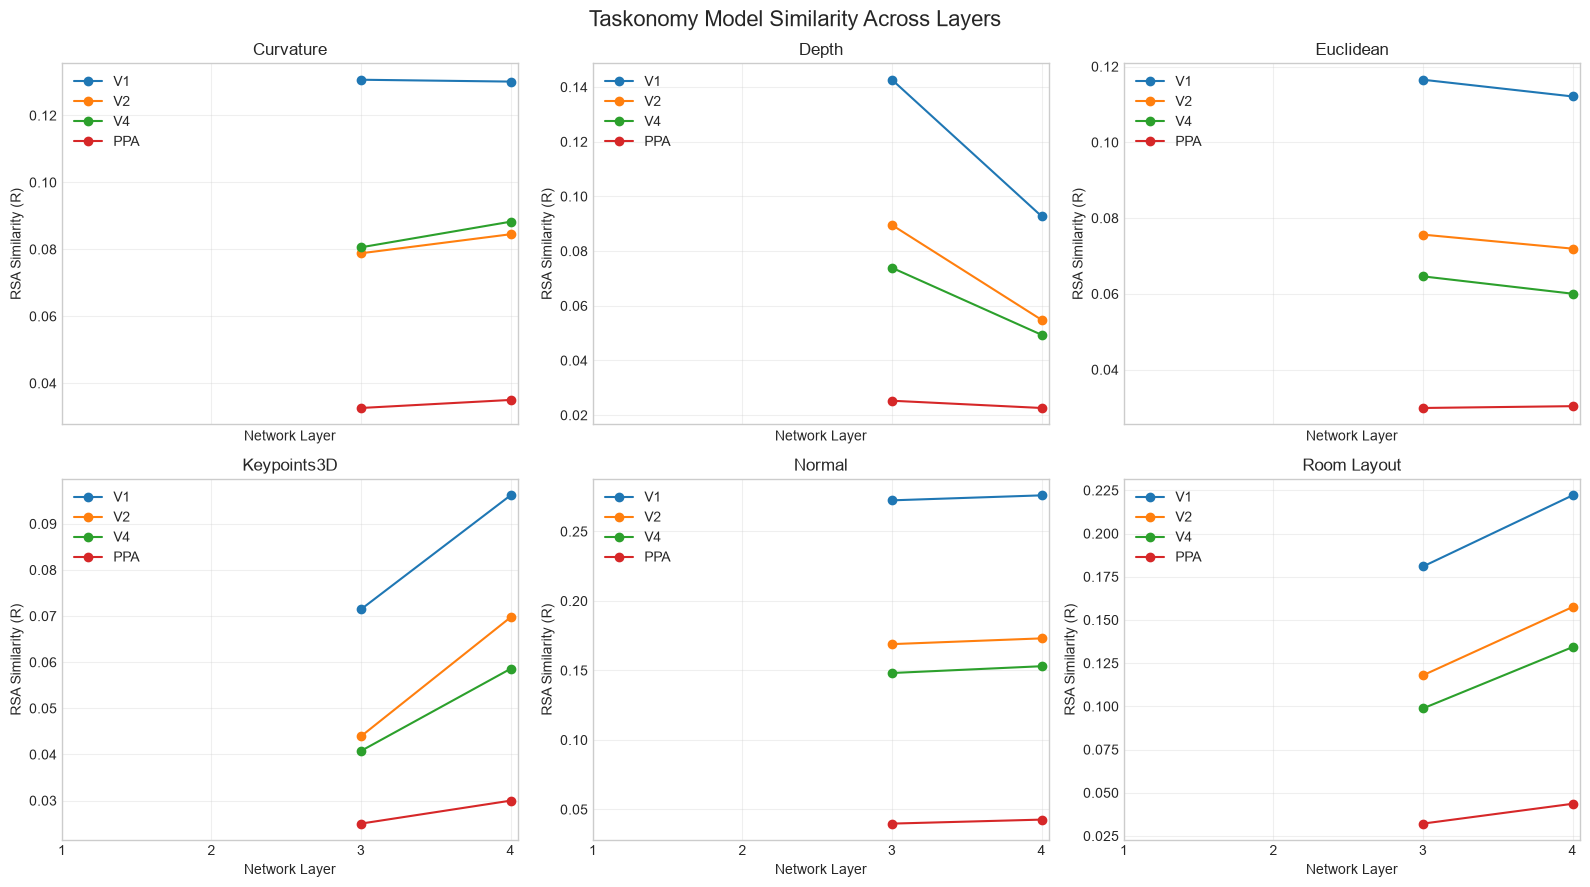

In [47]:
# brain-model similarity change as we move from Layer 1 → Layer 4
import matplotlib.pyplot as plt

models = df_plot_summary["Model"].unique()

roi_order = ["V1", "V2", "V4", "PPA"]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    sharex=True
)

axes = axes.flatten()


for ax, model_name in zip(axes, models):

    model_data = df_plot_summary[
        df_plot_summary["Model"] == model_name
    ]


    for roi_name in roi_order:

        roi_data = model_data[
            model_data["ROI_Group"] == roi_name
        ].sort_values("Layer_Number")


        ax.plot(
            roi_data["Layer_Number"],
            roi_data["R"],
            marker="o",
            label=roi_name
        )


    ax.set_title(model_name)

    ax.set_xlabel("Network Layer")

    ax.set_ylabel("RSA Similarity (R)")

    ax.set_xticks([1, 2, 3, 4])

    ax.grid(True, alpha=0.3)

    ax.legend()


plt.suptitle(
    "Taskonomy Model Similarity Across Layers",
    fontsize=16
)

plt.tight_layout()

plt.show()

## VPA


### VPA for 4 RDM (4 layers)

In [48]:
import os

print("Depth:")
print(os.listdir("Depth_RDMs_last2"))

print("\nEuclidean:")
print(os.listdir("Euclidean_RDMs_last2"))

print("\nKeypoints3D:")
print(os.listdir("Keypoints3D_RDMs_last2"))

print("\nNormal:")
print(os.listdir("Normal_RDMs_last2"))

Depth:
['RDM_layer3.npz', 'RDM_layer4.npz']

Euclidean:
['RDM_layer3.npz', 'RDM_layer4.npz']

Keypoints3D:
['RDM_layer3.npz', 'RDM_layer4.npz']

Normal:
['RDM_layer3.npz', 'RDM_layer4.npz']


In [49]:
from net2brain.evaluations.variance_partitioning_analysis import VPA
import os

depth_rdms = [os.path.join("Depth_RDMs_last2", "RDM_layer3.npz"),
            os.path.join("Depth_RDMs_last2", "RDM_layer4.npz")
]

euclidean_rdms = [
    os.path.join("Euclidean_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Euclidean_RDMs_last2", "RDM_layer4.npz")
]

keypoints3d_rdms = [
    os.path.join("Keypoints3D_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Keypoints3D_RDMs_last2", "RDM_layer4.npz")
]

normal_rdms = [
    os.path.join("Normal_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Normal_RDMs_last2", "RDM_layer4.npz")
]

for name, paths in {
    "Depth": depth_rdms,
    "Euclidean": euclidean_rdms,
    "Keypoints3D": keypoints3d_rdms,
    "Normal": normal_rdms
}.items():
    
    print(name)
    
    for path in paths:
        print(path, "→", os.path.exists(path))
    
    print()

Depth
Depth_RDMs_last2\RDM_layer3.npz → True
Depth_RDMs_last2\RDM_layer4.npz → True

Euclidean
Euclidean_RDMs_last2\RDM_layer3.npz → True
Euclidean_RDMs_last2\RDM_layer4.npz → True

Keypoints3D
Keypoints3D_RDMs_last2\RDM_layer3.npz → True
Keypoints3D_RDMs_last2\RDM_layer4.npz → True

Normal
Normal_RDMs_last2\RDM_layer3.npz → True
Normal_RDMs_last2\RDM_layer4.npz → True



In [50]:
independent_variables = [
    depth_rdms,
    euclidean_rdms,
    keypoints3d_rdms,
    normal_rdms
]

variable_names = [
    "Depth",
    "Euclidean",
    "Keypoints3D",
    "Normal"
]

In [51]:
from pathlib import Path

visual_brain_folder = (
    Path("..")
    / "bonner_pnas2017"
    / "brain_data"
)

ppa_brain_path = (
    Path("..")
    / "bonner_pnas2017"
    / "brain_data_live_study"
    / "fmri_ppa.npz"
)


brain_rois = {
    
    "V1d": visual_brain_folder / "fmri_V1d.npz",
    "V1v": visual_brain_folder / "fmri_V1v.npz",
    
    "V2d": visual_brain_folder / "fmri_V2d.npz",
    "V2v": visual_brain_folder / "fmri_V2v.npz",
    
    "V3a": visual_brain_folder / "fmri_V3a.npz",
    "V3b": visual_brain_folder / "fmri_V3b.npz",
    "V3d": visual_brain_folder / "fmri_V3d.npz",
    "V3v": visual_brain_folder / "fmri_V3v.npz",
    
    "hV4": visual_brain_folder / "fmri_hV4.npz",
    
    "LO1": visual_brain_folder / "fmri_LO1.npz",
    "LO2": visual_brain_folder / "fmri_LO2.npz",
    
    "VO1": visual_brain_folder / "fmri_VO1.npz",
    "VO2": visual_brain_folder / "fmri_VO2.npz",
    
    "PHC1": visual_brain_folder / "fmri_PHC1.npz",
    "PHC2": visual_brain_folder / "fmri_PHC2.npz",
    
    "PPA": ppa_brain_path
}


print("Number of ROIs:", len(brain_rois))

for roi_name, path in brain_rois.items():
    print(
        roi_name,
        "→",
        path,
        "→ Exists:",
        path.exists()
    )

Number of ROIs: 16
V1d → ..\bonner_pnas2017\brain_data\fmri_V1d.npz → Exists: True
V1v → ..\bonner_pnas2017\brain_data\fmri_V1v.npz → Exists: True
V2d → ..\bonner_pnas2017\brain_data\fmri_V2d.npz → Exists: True
V2v → ..\bonner_pnas2017\brain_data\fmri_V2v.npz → Exists: True
V3a → ..\bonner_pnas2017\brain_data\fmri_V3a.npz → Exists: True
V3b → ..\bonner_pnas2017\brain_data\fmri_V3b.npz → Exists: True
V3d → ..\bonner_pnas2017\brain_data\fmri_V3d.npz → Exists: True
V3v → ..\bonner_pnas2017\brain_data\fmri_V3v.npz → Exists: True
hV4 → ..\bonner_pnas2017\brain_data\fmri_hV4.npz → Exists: True
LO1 → ..\bonner_pnas2017\brain_data\fmri_LO1.npz → Exists: True
LO2 → ..\bonner_pnas2017\brain_data\fmri_LO2.npz → Exists: True
VO1 → ..\bonner_pnas2017\brain_data\fmri_VO1.npz → Exists: True
VO2 → ..\bonner_pnas2017\brain_data\fmri_VO2.npz → Exists: True
PHC1 → ..\bonner_pnas2017\brain_data\fmri_PHC1.npz → Exists: True
PHC2 → ..\bonner_pnas2017\brain_data\fmri_PHC2.npz → Exists: True
PPA → ..\bonner_p

In [52]:
import numpy as np
import os

vpa_brain_folder = "VPA_brain_data"

os.makedirs(
    vpa_brain_folder,
    exist_ok=True
)

brain_vpa_paths = {}

for roi_name, brain_path in brain_rois.items():

    # Load brain RDM
    brain_data = np.load(brain_path)["arr_0"]

    print(
        roi_name,
        "original shape:",
        brain_data.shape
    )


    # Get upper triangle indices
    triu_idx = np.triu_indices(
        brain_data.shape[1],
        k=1
    )


    # Convert:
    # (subjects, stimuli, stimuli)
    # →
    # (subjects, pairs)

    brain_vectorized = brain_data[
        :,
        triu_idx[0],
        triu_idx[1]
    ]


    # Add singleton time dimension:
    # (subjects, pairs)
    # →
    # (subjects, 1, pairs)

    brain_vpa = brain_vectorized[
        :,
        np.newaxis,
        :
    ]


    print(
        roi_name,
        "VPA shape:",
        brain_vpa.shape
    )


    # Save VPA-compatible brain data

    save_path = os.path.join(
        vpa_brain_folder,
        f"{roi_name}_vpa.npy"
    )


    np.save(
        save_path,
        brain_vpa
    )


    brain_vpa_paths[roi_name] = save_path


print("\nSaved brain VPA files:")

for roi_name, path in brain_vpa_paths.items():

    print(
        roi_name,
        "→",
        path,
        "→",
        os.path.exists(path)
    )

V1d original shape: (16, 50, 50)
V1d VPA shape: (16, 1, 1225)
V1v original shape: (16, 50, 50)
V1v VPA shape: (16, 1, 1225)
V2d original shape: (16, 50, 50)
V2d VPA shape: (16, 1, 1225)
V2v original shape: (16, 50, 50)
V2v VPA shape: (16, 1, 1225)
V3a original shape: (16, 50, 50)
V3a VPA shape: (16, 1, 1225)
V3b original shape: (16, 50, 50)
V3b VPA shape: (16, 1, 1225)
V3d original shape: (16, 50, 50)
V3d VPA shape: (16, 1, 1225)
V3v original shape: (16, 50, 50)
V3v VPA shape: (16, 1, 1225)
hV4 original shape: (16, 50, 50)
hV4 VPA shape: (16, 1, 1225)
LO1 original shape: (16, 50, 50)
LO1 VPA shape: (16, 1, 1225)
LO2 original shape: (16, 50, 50)
LO2 VPA shape: (16, 1, 1225)
VO1 original shape: (16, 50, 50)
VO1 VPA shape: (16, 1, 1225)
VO2 original shape: (16, 50, 50)
VO2 VPA shape: (16, 1, 1225)
PHC1 original shape: (16, 50, 50)
PHC1 VPA shape: (16, 1, 1225)
PHC2 original shape: (16, 50, 50)
PHC2 VPA shape: (16, 1, 1225)
PPA original shape: (16, 50, 50)
PPA VPA shape: (16, 1, 1225)

Sav

In [53]:
import pandas as pd

all_vpa_results = []

for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print(
        "Running VPA for:",
        roi_name
    )

    VPA_eval = VPA(

        dependent_variable_vpa,

        independent_variables,

        variable_names

    )

    df_vpa = VPA_eval.evaluate(

        average_models=True

    )

    # Add ROI name to result

    df_vpa["ROI"] = roi_name


    all_vpa_results.append(
        df_vpa
    )


# Combine all ROIs

df_vpa_all = pd.concat(

    all_vpa_results,

    ignore_index=True

)

print(
    "Final shape:",
    df_vpa_all.shape
)

display(
    df_vpa_all.head()
)

Running VPA for: V1d
Running VPA for: V1v
Running VPA for: V2d
Running VPA for: V2v
Running VPA for: V3a
Running VPA for: V3b
Running VPA for: V3d
Running VPA for: V3v
Running VPA for: hV4
Running VPA for: LO1
Running VPA for: LO2
Running VPA for: VO1
Running VPA for: VO2
Running VPA for: PHC1
Running VPA for: PHC2
Running VPA for: PPA
Final shape: (448, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,Depth Influence,"[[0.012938838536822761], [0.012323132921116753...",[8.300064555127789e-06],None,V1d
1,R2,Euclidean Influence,"[[0.014606553979692682], [0.011156610713976556...",[1.00585791202498e-06],None,V1d
2,R3,Keypoints3D Influence,"[[0.008730262627485774], [0.004583040790368642...",[2.4125735333846788e-06],None,V1d
3,R4,Normal Influence,"[[0.044593334913272886], [0.05073303177304722]...",[2.5097213490323204e-06],None,V1d
4,R12,Combined Depth and Euclidean Influence,"[[0.016161354852074594], [0.013755625503412139...",[1.289773643710254e-06],None,V1d


In [54]:
df_vpa_filtered = df_vpa_all.query(
    "Variable in ['y1234', 'y1', 'y2', 'y3', 'y4']"
).reset_index(drop=True)

display(df_vpa_filtered)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Depth,"[[0.0003335294419275492], [0.00036170270294544...",[0.0015465518263847588],None,V1d
1,y2,Unique Euclidean,"[[1.4932276525825294e-05], [7.580938599205389e...",[0.004507885318477085],None,V1d
2,y3,Unique Keypoints3D,"[[0.00045278373726098664], [0.0021266956432886...",[0.00017779988526246888],None,V1d
3,y4,Unique Normal,"[[0.030278316679097972], [0.04277404321985556]...",[7.850215562243124e-06],None,V1d
4,y1234,Shared Variance Depth and Euclidean and Keypoi...,"[[0.006721196822524367], [0.001606469963651546...",[0.00035226431553429886],None,V1d
...,...,...,...,...,...,...
75,y1,Unique Depth,"[[0.00016604618957627437], [0.0001281407008706...",[0.00770516100374727],None,PPA
76,y2,Unique Euclidean,"[[0.0007140255973513421], [0.00017058650336865...",[0.029618874795605307],None,PPA
77,y3,Unique Keypoints3D,"[[0.0016920987536830356], [6.63175223892809e-0...",[0.021913275133109218],None,PPA
78,y4,Unique Normal,"[[0.0010414012484775137], [0.00223539465768740...",[0.01033221329449545],None,PPA


In [55]:
df_vpa_plot = df_vpa_filtered.copy()

df_vpa_plot["Significance"] = (
    df_vpa_plot["Significance"].apply(
        lambda x:
        float(np.asarray(x).squeeze())
    )
)

display(df_vpa_plot)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Depth,"[[0.0003335294419275492], [0.00036170270294544...",0.001547,None,V1d
1,y2,Unique Euclidean,"[[1.4932276525825294e-05], [7.580938599205389e...",0.004508,None,V1d
2,y3,Unique Keypoints3D,"[[0.00045278373726098664], [0.0021266956432886...",0.000178,None,V1d
3,y4,Unique Normal,"[[0.030278316679097972], [0.04277404321985556]...",0.000008,None,V1d
4,y1234,Shared Variance Depth and Euclidean and Keypoi...,"[[0.006721196822524367], [0.001606469963651546...",0.000352,None,V1d
...,...,...,...,...,...,...
75,y1,Unique Depth,"[[0.00016604618957627437], [0.0001281407008706...",0.007705,None,PPA
76,y2,Unique Euclidean,"[[0.0007140255973513421], [0.00017058650336865...",0.029619,None,PPA
77,y3,Unique Keypoints3D,"[[0.0016920987536830356], [6.63175223892809e-0...",0.021913,None,PPA
78,y4,Unique Normal,"[[0.0010414012484775137], [0.00223539465768740...",0.010332,None,PPA


In [56]:
print("ROIs:")
print(df_vpa_plot["ROI"].unique())
print("\nVariables:")
print(df_vpa_plot["Variable"].unique())
print("\nNumber of results per ROI:")
print(df_vpa_plot.groupby("ROI").size())

ROIs:
['V1d' 'V1v' 'V2d' 'V2v' 'V3a' 'V3b' 'V3d' 'V3v' 'hV4' 'LO1' 'LO2' 'VO1'
 'VO2' 'PHC1' 'PHC2' 'PPA']

Variables:
['y1' 'y2' 'y3' 'y4' 'y1234']

Number of results per ROI:
ROI
LO1     5
LO2     5
PHC1    5
PHC2    5
PPA     5
V1d     5
V1v     5
V2d     5
V2v     5
V3a     5
V3b     5
V3d     5
V3v     5
VO1     5
VO2     5
hV4     5
dtype: int64


V1d


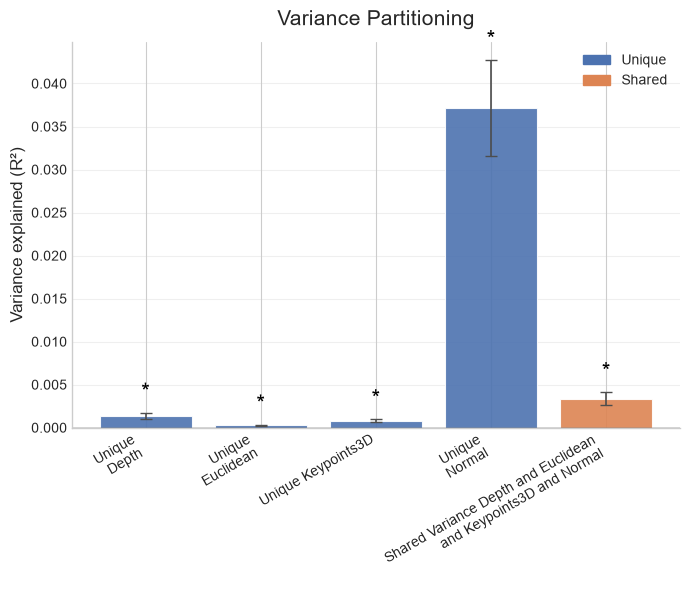

V2d


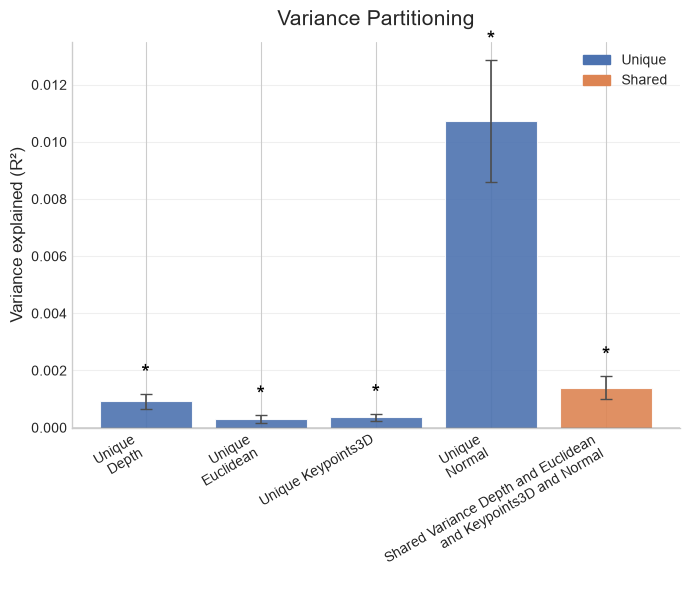

LO1


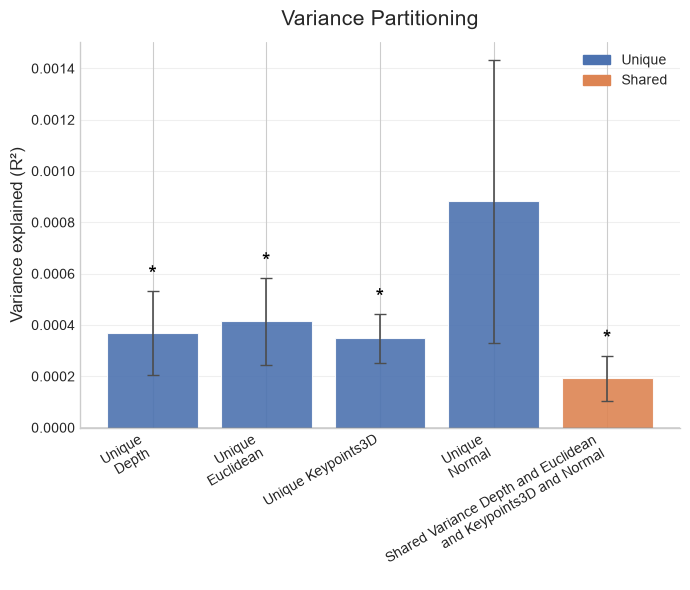

PPA


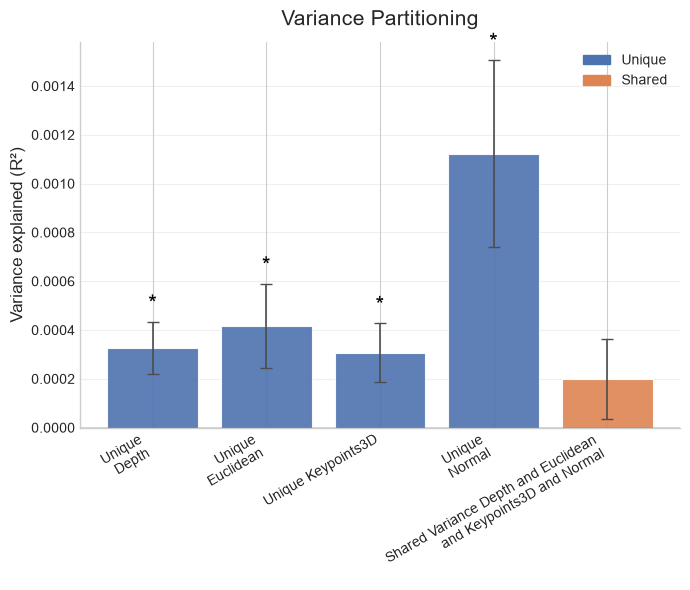

In [57]:
from net2brain.evaluations.plotting import Plotting

# df_ppa_vpa = df_vpa_plot[df_vpa_plot["ROI"] == "PPA"].copy()

for roi in ["V1d", "V2d", "LO1", "PPA"]:  # other ROIs can be added here

    print(roi)

    df_roi = df_vpa_plot[
        df_vpa_plot["ROI"] == roi
    ]

    plotter = Plotting(df_roi)
    plotter.plotting_components()

In [58]:
import numpy as np

df_plot = df_vpa_plot.copy()

df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: np.mean(np.asarray(x))
)

#df_plot["Std"] = df_plot["Values"].apply(
#   lambda x: np.std(np.asarray(x), ddof=1))

df_plot["SEM"] = df_plot["Values"].apply(
    lambda x: np.std(np.asarray(x), ddof=1)
              / np.sqrt(len(np.asarray(x)))
)

In [59]:
import pandas as pd

pivot = df_plot.pivot(
    index="ROI",
    columns="Variable",
    values="Mean"
)

display(pivot.head())

Variable,y1,y1234,y2,y3,y4
ROI,,,,,
LO1,0.000368,0.000192,0.000414,0.000348,0.000882
LO2,0.000382,0.000314,0.000792,0.000532,0.000462
PHC1,0.000424,0.000151,0.000782,0.000651,0.001586
PHC2,0.000294,-0.000023,0.000706,0.000710,0.000883
PPA,0.000327,0.000199,0.000417,0.000307,0.001123


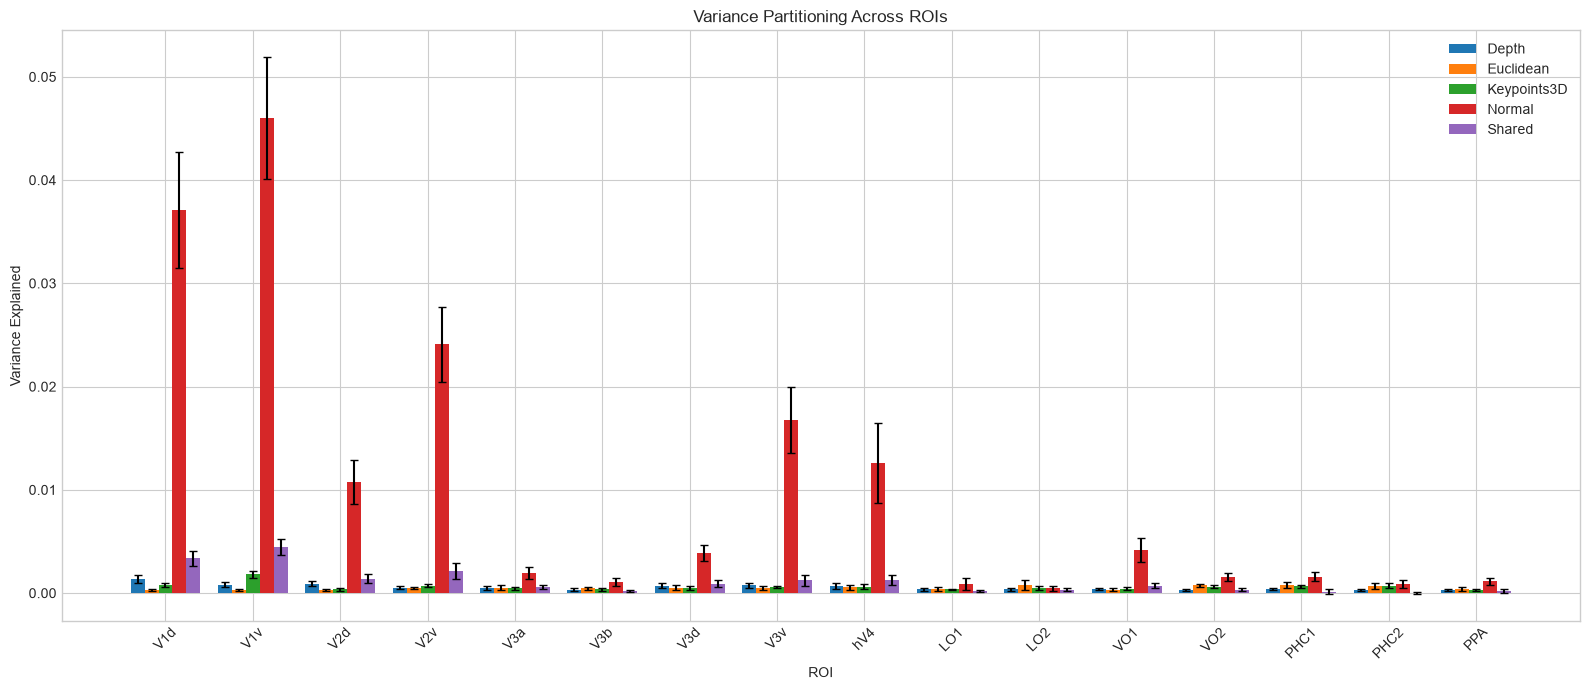

In [60]:
import matplotlib.pyplot as plt
import numpy as np

name_map = {
    "y1": "Depth",
    "y2": "Euclidean",
    "y3": "Keypoints3D",
    "y4": "Normal",
    "y1234": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

rois = list(df_plot["ROI"].unique())
components = ["Depth", "Euclidean", "Keypoints3D", "Normal", "Shared"]

x = np.arange(len(rois))
width = 0.16

fig, ax = plt.subplots(figsize=(16, 7))

for i, comp in enumerate(components):

    subset = df_plot[df_plot["Component"] == comp]

    means = []
    sems = []       #stds = []

    for roi in rois:
        row = subset[subset["ROI"] == roi].iloc[0]
        means.append(row["Mean"])
        sems.append(row["SEM"])  # stds.append(row["Std"])

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        label=comp,
        yerr=sems, #stds,
        capsize=3
    )

ax.set_xticks(x)
ax.set_xticklabels(rois, rotation=45)
ax.set_ylabel("Variance Explained")
ax.set_xlabel("ROI")
ax.set_title("Variance Partitioning Across ROIs")
ax.legend()

plt.tight_layout()
plt.show()

## Combine Average 3D

In [2]:
import numpy as np
from pathlib import Path

# 3D TASKONOMY RDM COMBINATION

models_3d = {
    "Depth": Path("Depth_RDMs_last2"),
    "Euclidean": Path("Euclidean_RDMs_last2"),
    "KeyPoints3D": Path("KeyPoints3D_RDMs_last2"),
    "Normal": Path("Normal_RDMs_last2"),
}

# Output file
output_file = Path("3D_RDM.npz")

# Last two ResNet-50 encoder layers
layers = ["RDM_layer3.npz", "RDM_layer4.npz"]

# Helper function
def load_rdm(path):
    """Load the RDM array from a Net2Brain .npz file."""
    
    data = np.load(path, allow_pickle=True)
    
    print(f"\nLoading: {path}")
    print("Keys:", data.files)
    
    if "rdm" not in data.files:
        raise KeyError(f"'rdm' not found in {path}. Available keys: {data.files}")
    
    rdm = data["rdm"]
    
    # Handle object arrays if necessary
    if rdm.dtype == object and rdm.ndim == 0:
        rdm = rdm.item()
    
    rdm = np.asarray(rdm, dtype=float)
    
    print("Shape:", rdm.shape)
    
    return rdm

# Load all selected model/layer RDMs
rdms = []

for model_name, model_path in models_3d.items():
    
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    
    if not model_path.exists():
        raise FileNotFoundError(
            f"Folder not found: {model_path.resolve()}"
        )
    
    for layer_file in layers:
        
        rdm_path = model_path / layer_file
        
        if not rdm_path.exists():
            raise FileNotFoundError(
                f"RDM file not found: {rdm_path.resolve()}"
            )
        
        rdm = load_rdm(rdm_path)
        
        rdms.append(rdm)

# Check that all RDMs have the same shape
print("\n" + "=" * 60)
print("CHECKING RDM SHAPES")
print("=" * 60)

for i, rdm in enumerate(rdms):
    print(f"RDM {i+1}: {rdm.shape}")

shapes = [rdm.shape for rdm in rdms]

if len(set(shapes)) != 1:
    raise ValueError(
        f"RDM shapes are not identical: {shapes}"
    )

print("\nAll RDMs have the same shape:", shapes[0])

# Average all selected model/layer RDMs
rdms_stack = np.stack(rdms, axis=0)

print("\nStacked RDM shape:", rdms_stack.shape)

rdm_3d = np.mean(rdms_stack, axis=0)

print("Combined 3D RDM shape:", rdm_3d.shape)

# Save
np.savez(
    output_file,
    rdm=rdm_3d
)

print("\nSaved combined 3D RDM to:")
print(output_file.resolve())

# Basic verification

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

print("Minimum:", np.min(rdm_3d))
print("Maximum:", np.max(rdm_3d))
print("Mean:", np.mean(rdm_3d))
print("NaN:", np.isnan(rdm_3d).any())
print("Inf:", np.isinf(rdm_3d).any())


Depth

Loading: Depth_RDMs_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Loading: Depth_RDMs_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Euclidean

Loading: Euclidean_RDMs_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Loading: Euclidean_RDMs_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

KeyPoints3D

Loading: KeyPoints3D_RDMs_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Loading: KeyPoints3D_RDMs_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Normal

Loading: Normal_RDMs_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

Loading: Normal_RDMs_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (1225,)

CHECKING RDM SHAPES
RDM 1: (1225,)
RDM 2: (1225,)
RDM 3: (1225,)
R

In [1]:
import numpy as np
from pathlib import Path

models_3d = {
    "Depth": Path("Depth_RDMs_last2"),
    "Euclidean": Path("Euclidean_RDMs_last2"),
    "KeyPoints3D": Path("KeyPoints3D_RDMs_last2"),
    "Normal": Path("Normal_RDMs_last2"),
}

reference = None

for model_name, folder in models_3d.items():
    for layer in ["RDM_layer3.npz", "RDM_layer4.npz"]:
        path = folder / layer
        data = np.load(path, allow_pickle=True)

        stimuli = data["stimuli_name"]

        if reference is None:
            reference = stimuli
            print(f"Reference: {model_name} {layer}")
        else:
            same = np.array_equal(reference, stimuli)
            print(f"{model_name} {layer}: same stimulus order = {same}")

            if not same:
                print("WARNING: stimulus order differs!")

Reference: Depth RDM_layer3.npz
Depth RDM_layer4.npz: same stimulus order = True
Euclidean RDM_layer3.npz: same stimulus order = True
Euclidean RDM_layer4.npz: same stimulus order = True
KeyPoints3D RDM_layer3.npz: same stimulus order = True
KeyPoints3D RDM_layer4.npz: same stimulus order = True
Normal RDM_layer3.npz: same stimulus order = True
Normal RDM_layer4.npz: same stimulus order = True


## averaging 3D RDM (ignore)

In [61]:
import os

brain_data_folder = "../bonner_pnas2017/brain_data_live_study"

print(os.listdir(brain_data_folder))

['fmri_ppa.npz', 'fmri_ppa_vpa_vectorized.npz', 'noise_ceiling_log.json']


In [62]:
import os

depth_rdms = [
    os.path.join("Depth_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Depth_RDMs_last2", "RDM_layer4.npz")
]

euclidean_rdms = [
    os.path.join("Euclidean_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Euclidean_RDMs_last2", "RDM_layer4.npz")
]

keypoints3d_rdms = [
    os.path.join("Keypoints3D_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Keypoints3D_RDMs_last2", "RDM_layer4.npz")
]

normal_rdms = [
    os.path.join("Normal_RDMs_last2", "RDM_layer3.npz"),
    os.path.join("Normal_RDMs_last2", "RDM_layer4.npz")
]

threeD_rdms = (
    depth_rdms
    + euclidean_rdms
    + keypoints3d_rdms
    + normal_rdms
)

#twoD_rdms = [...]
#semantic_rdms = [...]

print("Number of 3D RDMs:", len(threeD_rdms))

for path in threeD_rdms:
    print(path, "→", os.path.exists(path))

Number of 3D RDMs: 8
Depth_RDMs_last2\RDM_layer3.npz → True
Depth_RDMs_last2\RDM_layer4.npz → True
Euclidean_RDMs_last2\RDM_layer3.npz → True
Euclidean_RDMs_last2\RDM_layer4.npz → True
Keypoints3D_RDMs_last2\RDM_layer3.npz → True
Keypoints3D_RDMs_last2\RDM_layer4.npz → True
Normal_RDMs_last2\RDM_layer3.npz → True
Normal_RDMs_last2\RDM_layer4.npz → True


In [63]:
from net2brain.evaluations.variance_partitioning_analysis import VPA

In [64]:
independent_variables = [

    twoD_rdms,

    threeD_rdms,

    semantic_rdms

]


variable_names = [

    "2D",

    "3D",

    "Semantic"

]

NameError: name 'twoD_rdms' is not defined

In [ ]:
VPA_eval = VPA(

    dependent_variable_vpa,

    independent_variables,

    variable_names

)


df_vpa = VPA_eval.evaluate(

    average_models=True

)

display(df_vpa)

In [ ]:
df_vpa_filtered = df_vpa.query(

    "Variable in ['y123', 'y1', 'y2', 'y3']"

).reset_index(drop=True)

display(df_vpa_filtered)

In [ ]:
import numpy as np

df_vpa_plot = df_vpa_filtered.copy()

df_vpa_plot["Significance"] = df_vpa_plot[
    "Significance"
].apply(
    lambda x: float(np.asarray(x).squeeze())
)

display(df_vpa_plot)

In [ ]:
from net2brain.evaluations.plotting import Plotting

plotter = Plotting(df_vpa_plot)

plotter.plotting_components()